# DES model selection (ML)

## Loading packages

In [21]:
library("stringr")
library("tidyverse")
library("ggpubr")
library("rstatix")

## Creating useful functions for list append

In [22]:
lappend <- function (lst, ...){
lst <- c(lst, list(...))
  return(lst)
}

## Listing files in directory

In [23]:
list_all_dir <- c("Analysis_ML/gen_1", "Analysis_ML/sp_1")

## Looping over all directory and files

In [24]:
list_prop <- list()
dir_name <- c("gen_1", "sp_1")
for (dir in list_all_dir){
    list_all_files <- list.files(dir, pattern = "Mlsbplx.log", full.names = TRUE)
    AIC <- c()
    for (files in list_all_files){
        temp_tab <- read.table(files, sep ="\t", header = TRUE)
        AIC <- c(AIC, temp_tab$AICc)
        }
    
    splt_1 <- str_split_fixed(list_all_files, pattern = "_DES_", 2)[,2]
    splt_2_1 <- str_split_fixed(splt_1, pattern = "_", 2)[,1]
    splt_2_2 <- str_split_fixed(splt_1, pattern = "_", 2)[,2]
    splt_3 <- str_split_fixed(splt_2_2, pattern = "0_q_", 2)[,2]
    splt_4 <- str_split_fixed(splt_3, pattern = "_TdD_TdE_G_Mlsbplx.log", 2)[,1]
    splt_4[splt_4 == ""] <- "0"
    Replicate <- splt_2_1
    Model <- splt_4
        
    df<-as.data.frame(cbind(Model, AIC, Replicate))

    df$AIC <- as.numeric(AIC)

    nb_rep <- 0
    nb_best_model <- rep(0,5)
    for( i in unique((Replicate))){
        temp_df <- df[df$Replicate == i,]
            
        if(nrow(temp_df) == 5){
            nb_rep <- nb_rep + 1
            nb_best_model[which.min(temp_df$AIC)] <- nb_best_model[which.min(temp_df$AIC)] + 1
        }
    }
    
    prop_best_model <- nb_best_model/nb_rep
    names(prop_best_model) <- c("All shifts", "Two shifts", "One shift (33.9)", "One shift (66)", "No shift")
    list_prop <- lappend(list_prop, prop_best_model)
}
names(list_prop) <- dir_name

In [25]:
list_prop

$gen_1
      All shifts       Two shifts One shift (33.9)   One shift (66) 
            0.65             0.32             0.03             0.00 
        No shift 
            0.00 

$sp_1
      All shifts       Two shifts One shift (33.9)   One shift (66) 
            0.89             0.04             0.00             0.00 
        No shift 
            0.07

## Save the output

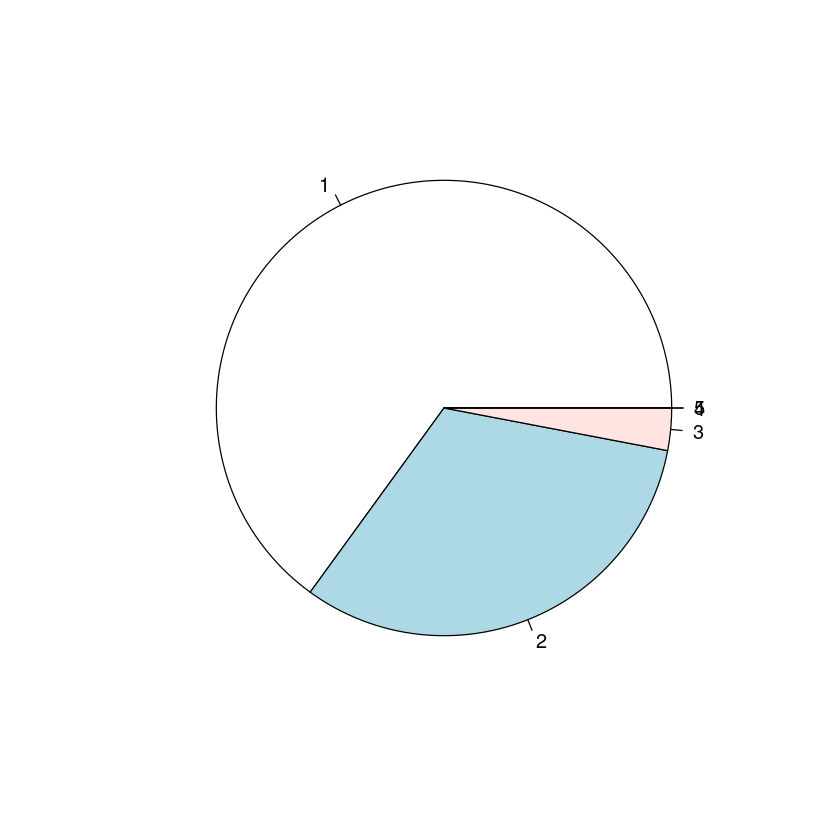

$gen_1
NULL

$sp_1
NULL

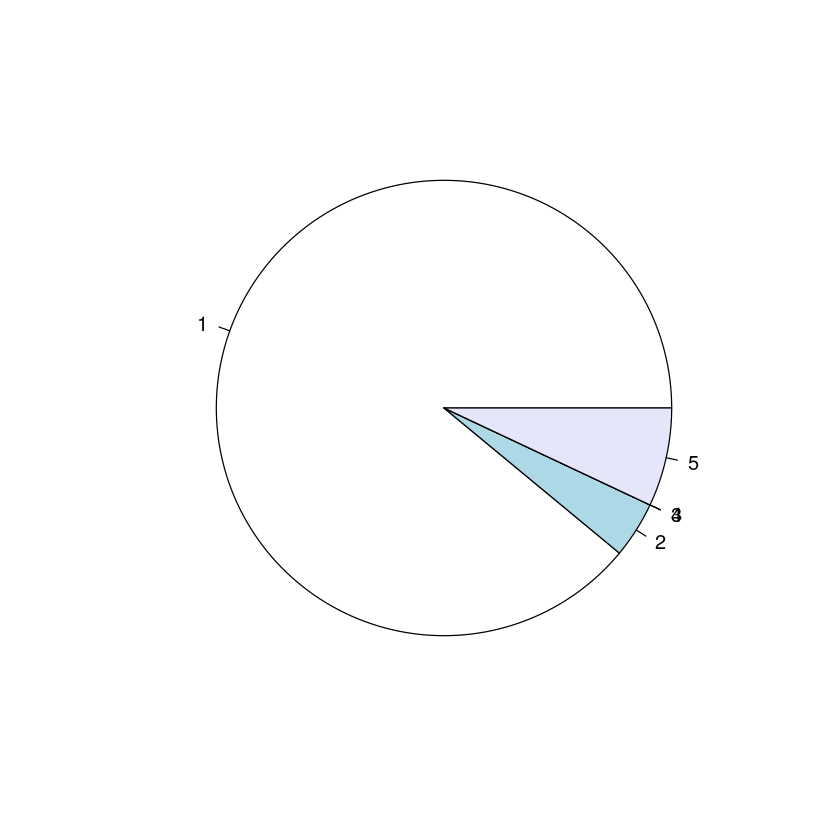

In [26]:
lapply(X = list_prop, FUN = pie, , labels = NULL)